In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


 Part 1: Load Data

In [2]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


print(df.head())
print()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  



Part 2: Model-Based Agent Class

In [3]:
class ModelBasedAgent:
    def __init__(self):
        self.state = None
    
    def update_state(self, perception):
        """Update agent's internal state"""
        self.state = perception
    
    def choose_action(self):
        """Choose action based on rules"""
        petal_length = self.state[2]
        
        if petal_length < 2:
            return "setosa"
        elif petal_length < 5:
            return "versicolor"
        else:
            return "virginica"
    
    def predict(self, X):
        """Predict for multiple samples"""
        predictions = []
        for perception in X:
            self.update_state(perception)
            action = self.choose_action()
            # Convert to numeric
            if action == "setosa":
                predictions.append(0)
            elif action == "versicolor":
                predictions.append(1)
            else:
                predictions.append(2)
        return np.array(predictions)


Part 3: Test Agent on First 5 Samples

In [4]:

agent = ModelBasedAgent()

for i in range(5):
    perception = df.iloc[i][:4].values
    agent.update_state(perception)
    action = agent.choose_action()
    actual = data.target_names[int(df.iloc[i]['target'])]
    
    print(f"Sample {i+1}:")
    print(f"  Input: {perception}")
    print(f"  Agent Prediction: {action}")
    print(f"  Actual: {actual}")
    print(f"  Correct: {'✓' if action == actual else '✗'}")
    print("-"*60)

print()

Sample 1:
  Input: [5.1 3.5 1.4 0.2]
  Agent Prediction: setosa
  Actual: setosa
  Correct: ✓
------------------------------------------------------------
Sample 2:
  Input: [4.9 3.  1.4 0.2]
  Agent Prediction: setosa
  Actual: setosa
  Correct: ✓
------------------------------------------------------------
Sample 3:
  Input: [4.7 3.2 1.3 0.2]
  Agent Prediction: setosa
  Actual: setosa
  Correct: ✓
------------------------------------------------------------
Sample 4:
  Input: [4.6 3.1 1.5 0.2]
  Agent Prediction: setosa
  Actual: setosa
  Correct: ✓
------------------------------------------------------------
Sample 5:
  Input: [5.  3.6 1.4 0.2]
  Agent Prediction: setosa
  Actual: setosa
  Correct: ✓
------------------------------------------------------------



Part 4: Evaluate on Entire Dataset

In [5]:

X = df.iloc[:, :4].values
y_true = df['target'].values

# Get predictions
y_pred = agent.predict(X)

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")
print()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=data.target_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
print()

Overall Accuracy: 94.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.89      0.96      0.92        50
   virginica       0.96      0.88      0.92        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

Confusion Matrix:
[[50  0  0]
 [ 0 48  2]
 [ 0  6 44]]



Part 5: Visualization - Confusion Matrix

✓ Confusion matrix saved as 'confusion_matrix.png'


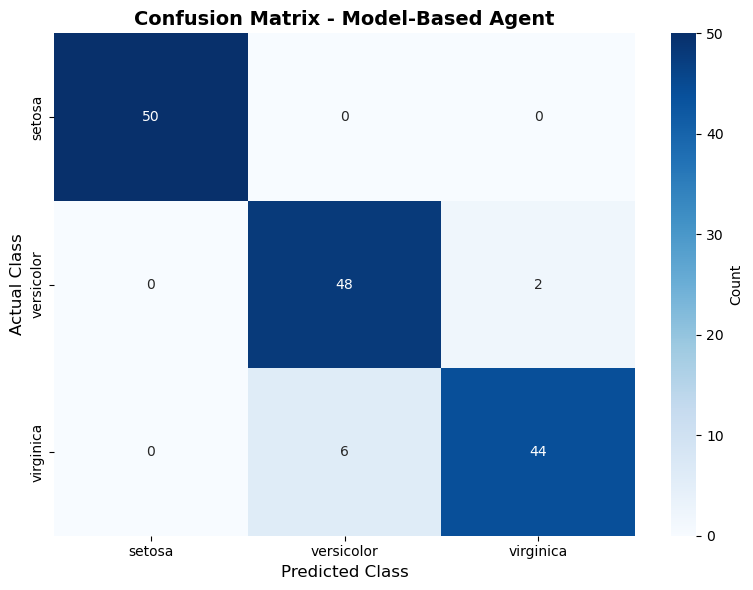

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Model-Based Agent', fontsize=14, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved as 'confusion_matrix.png'")
plt.show()

Part 6: Feature Distribution Analysis

✓ Feature distributions saved as 'feature_distributions.png'


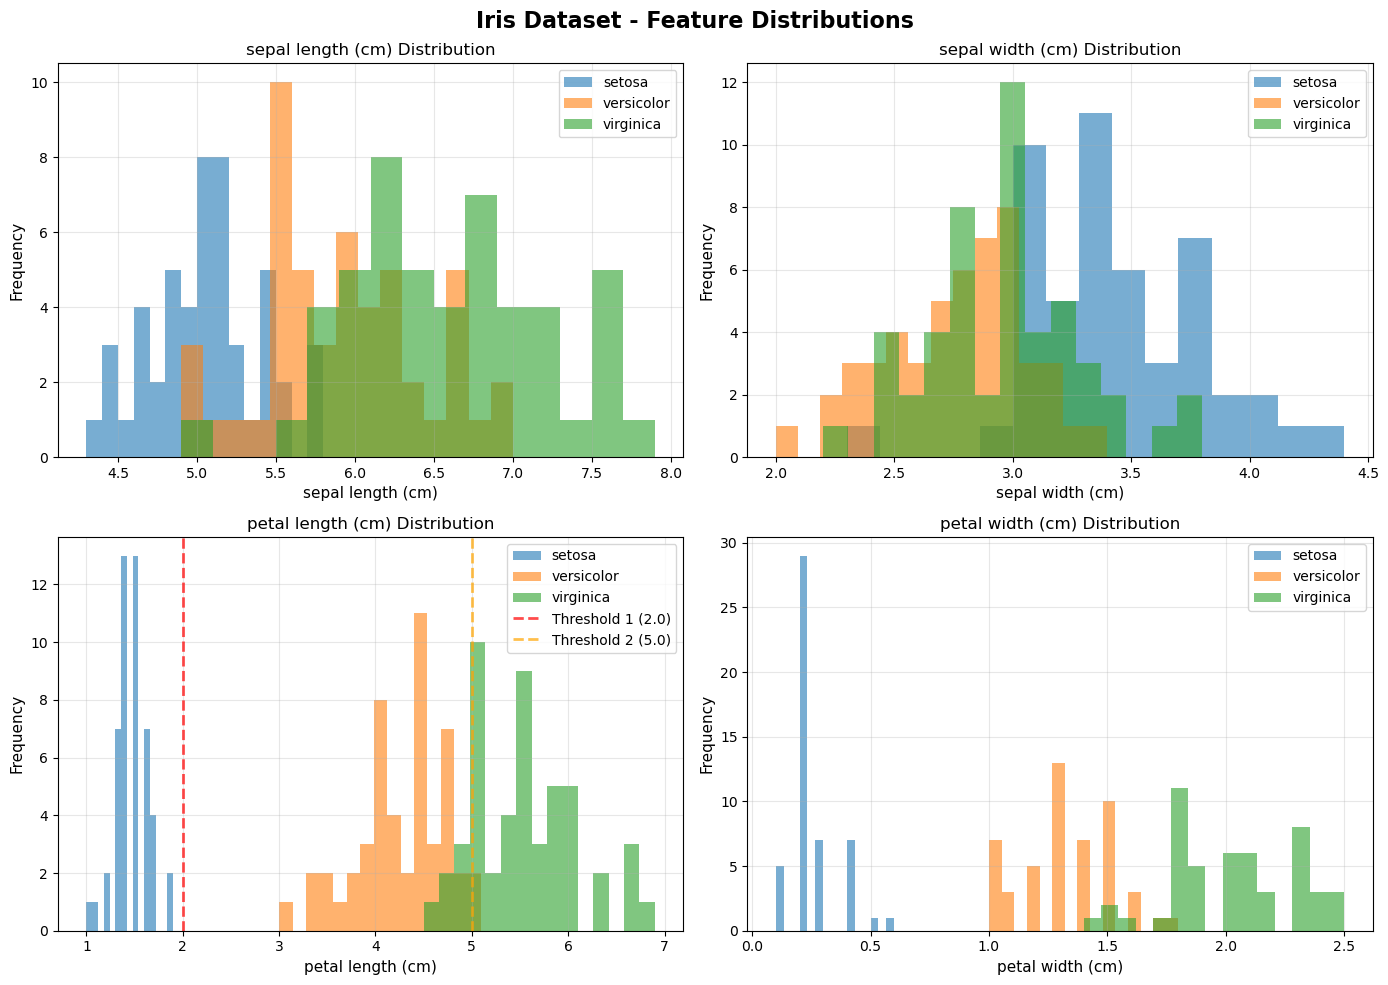

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset - Feature Distributions', fontsize=16, fontweight='bold')

features = ['sepal length (cm)', 'sepal width (cm)', 
            'petal length (cm)', 'petal width (cm)']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    
    for i, name in enumerate(data.target_names):
        subset = df[df['target'] == i][feature]
        ax.hist(subset, alpha=0.6, label=name, bins=15)
    
    # Add threshold lines for petal length
    if feature == 'petal length (cm)':
        ax.axvline(x=2, color='red', linestyle='--', linewidth=2, 
                   label='Threshold 1 (2.0)', alpha=0.7)
        ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, 
                   label='Threshold 2 (5.0)', alpha=0.7)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{feature} Distribution', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Feature distributions saved as 'feature_distributions.png'")
plt.show()

Part 7: Petal Length vs Petal Width

✓ Decision boundaries saved as 'decision_boundaries.png'


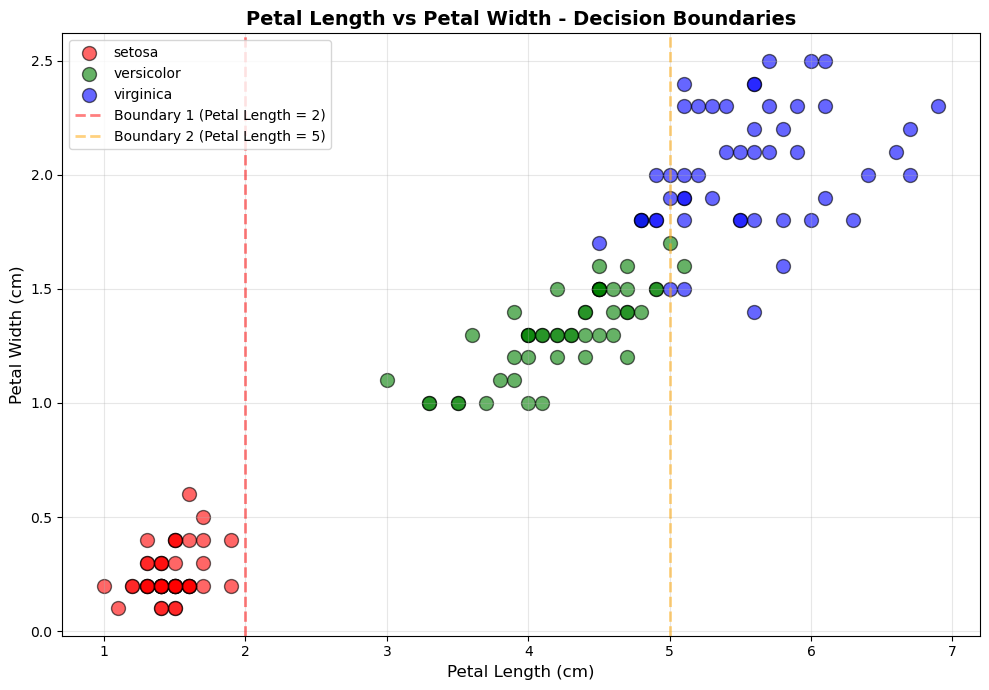

In [8]:
plt.figure(figsize=(10, 7))

colors = ['red', 'green', 'blue']
for i, name in enumerate(data.target_names):
    subset = df[df['target'] == i]
    plt.scatter(subset['petal length (cm)'], 
               subset['petal width (cm)'],
               c=colors[i], label=name, alpha=0.6, s=100, edgecolors='black')

# Add decision boundaries
plt.axvline(x=2, color='red', linestyle='--', linewidth=2, 
            label='Boundary 1 (Petal Length = 2)', alpha=0.5)
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, 
            label='Boundary 2 (Petal Length = 5)', alpha=0.5)

plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.title('Petal Length vs Petal Width - Decision Boundaries', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=300, bbox_inches='tight')
print("✓ Decision boundaries saved as 'decision_boundaries.png'")
plt.show()

Part 8: Comparison with ML Models

In [9]:

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_true, test_size=0.3, random_state=42, stratify=y_true
)

# Model 1: Model-Based Agent
agent_pred = agent.predict(X_test)
agent_acc = accuracy_score(y_test, agent_pred)

# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Model 3: XGBoost
xgb = XGBClassifier(max_depth=3, n_estimators=50, random_state=42, 
                    eval_metric='mlogloss', use_label_encoder=False)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

# Results
results = pd.DataFrame({
    'Model': ['Model-Based Agent', 'Decision Tree', 'XGBoost'],
    'Accuracy': [agent_acc, dt_acc, xgb_acc]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))
print()

            Model  Accuracy
    Decision Tree  0.977778
          XGBoost  0.933333
Model-Based Agent  0.911111



C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:12:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Part 9: Comparison Visualization

✓ Model comparison saved as 'model_comparison.png'


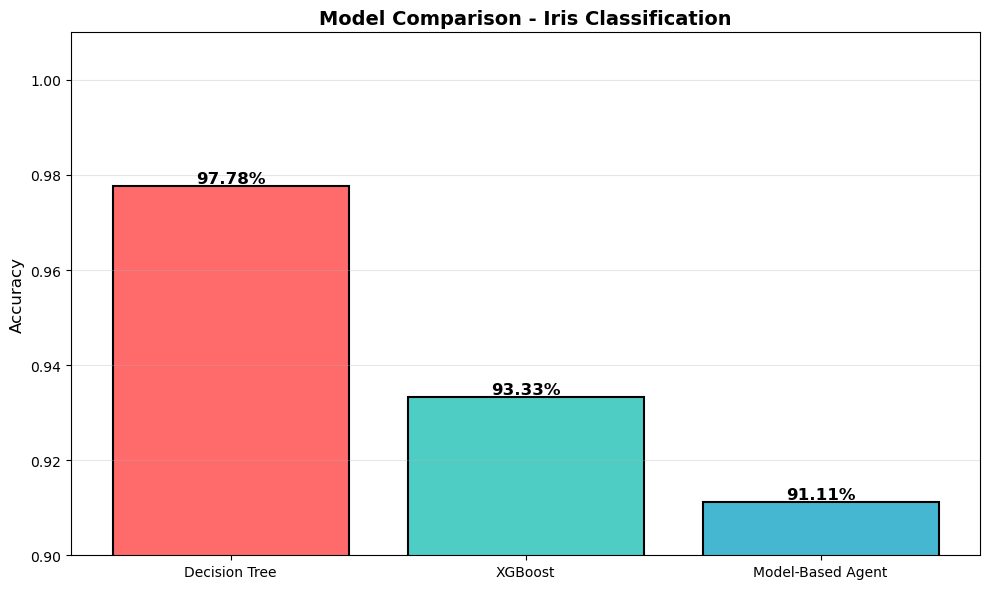

In [10]:
plt.figure(figsize=(10, 6))
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(results['Model'], results['Accuracy'], color=colors_bar, 
               edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison - Iris Classification', fontsize=14, fontweight='bold')
plt.ylim([0.9, 1.01])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Model comparison saved as 'model_comparison.png'")
plt.show()

Part 10: Summary Statistics

In [11]:

summary_stats = df.groupby('target')['petal length (cm)'].describe()
summary_stats.index = data.target_names
print(summary_stats)
print()

print("="*60)
print("AGENT DECISION RULES:")
print("="*60)
print("IF Petal Length < 2.0 cm   → Setosa")
print("IF 2.0 ≤ Petal Length < 5.0 → Versicolor")
print("IF Petal Length ≥ 5.0 cm   → Virginica")
print("="*60)

print("\n✅ All done! Check the generated images.")

            count   mean       std  min  25%   50%    75%  max
setosa       50.0  1.462  0.173664  1.0  1.4  1.50  1.575  1.9
versicolor   50.0  4.260  0.469911  3.0  4.0  4.35  4.600  5.1
virginica    50.0  5.552  0.551895  4.5  5.1  5.55  5.875  6.9

AGENT DECISION RULES:
IF Petal Length < 2.0 cm   → Setosa
IF 2.0 ≤ Petal Length < 5.0 → Versicolor
IF Petal Length ≥ 5.0 cm   → Virginica

✅ All done! Check the generated images.
